### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

In [9]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9
...,...,...,...,...,...
188,Venezuela,333,100,3,7.7
189,Vietnam,111,2,1,2.0
190,Yemen,6,0,0,0.1
191,Zambia,32,19,4,2.5


In [ ]:
#primi 10 paesi per consumo alcolico
df.sort_values(by='total_litres_of_pure_alcohol',ascending=False,inplace=True)
print(df.head(10))

                country  beer_servings  spirit_servings  wine_servings  \
15              Belarus            142              373             42   
98            Lithuania            343              244             56   
3               Andorra            245              138            312   
68              Grenada            199              438             28   
45       Czech Republic            361              170            134   
61               France            127              151            370   
141  Russian Federation            247              326             73   
81              Ireland            313              118            165   
155            Slovakia            196              293            116   
99           Luxembourg            236              133            271   

     total_litres_of_pure_alcohol  
15                           14.4  
98                           12.9  
3                            12.4  
68                           11.9  
45   

In [6]:
#media consumo birra, vino e distillati
print("Media del consumo di birra:", df['beer_servings'].mean())
print("Media del consumo di vino:", df['wine_servings'].mean())
print("Media del consumo di distillati:", df['spirit_servings'].mean())

Media del consumo di birra: 106.16062176165804
Media del consumo di vino: 49.45077720207254
Media del consumo di distillati: 80.99481865284974


In [15]:
# Nuova colonna alcohol_index
df['alcohol_index'] = (df['beer_servings'] + df['wine_servings'] + df['spirit_servings']) / 3
print(df['alcohol_index'])


0        0.000000
1       91.666667
2       13.000000
3      231.666667
4      106.333333
          ...    
188    145.333333
189     38.000000
190      2.000000
191     18.333333
192     28.666667
Name: alcohol_index, Length: 193, dtype: float64


In [23]:
#Paese con il massimo alcohol_index
print(df.loc[df['alcohol_index'].idxmax()])

country                            Andorra
beer_servings                          245
spirit_servings                        138
wine_servings                          312
total_litres_of_pure_alcohol          12.4
alcohol_index                   231.666667
Name: 3, dtype: object


In [25]:
# Trovo solo i paesi che consumano più di 100 birre all'anno
print(df[df['beer_servings'] > 100])

               country  beer_servings  spirit_servings  wine_servings  \
3              Andorra            245              138            312   
4               Angola            217               57             45   
5    Antigua & Barbuda            102              128             45   
6            Argentina            193               25            221   
8            Australia            261               72            212   
..                 ...            ...              ...            ...   
182     United Kingdom            219              126            195   
184                USA            249              158             84   
185            Uruguay            115               35            220   
188          Venezuela            333              100              3   
189            Vietnam            111                2              1   

     total_litres_of_pure_alcohol  alcohol_index  
3                            12.4     231.666667  
4                    

Text(0, 0.5, 'Litri Totali')

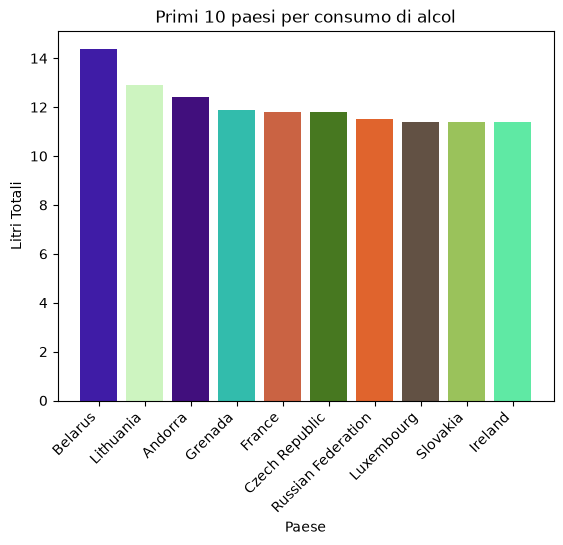

In [62]:
import matplotlib.pyplot as plt
import numpy as np
# Bar plot dei primi 10 paesi per alcohol serving
df.sort_values(by='total_litres_of_pure_alcohol',ascending=False,inplace=True)
cat = df.head(10)['country']
val = df.head(10)['total_litres_of_pure_alcohol']
col = np.random.rand(len(cat), 3)

plt.bar(cat, val, color = col)
plt.xticks(rotation=45, ha='right')
plt.title('Primi 10 paesi per consumo di alcol')
plt.xlabel("Paese")
plt.ylabel("Litri Totali")

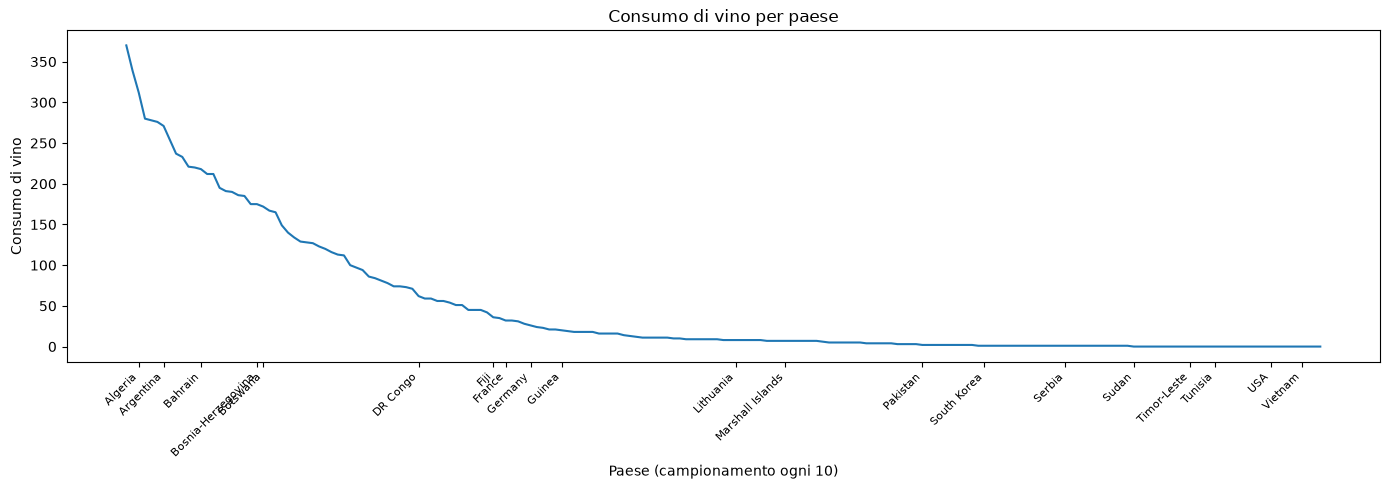

In [70]:
# Line plot per wine_servings per paese
df.sort_values(by='wine_servings',ascending=False,inplace=True)
x = df['country']
y = df['wine_servings']

plt.figure(figsize=(14, 5))
plt.plot(x,y)
plt.title('Consumo di vino per paese')
plt.xlabel('Paese (campionamento ogni 10)')
plt.ylabel('Consumo di vino')
passo = 10
posizioni = df.index[::passo]
etichette = df['country'][::passo]
plt.xticks(posizioni, etichette, rotation=45, ha='right',fontsize=8)
plt.tight_layout()

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

In [123]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])



In [124]:
#Ripulisco il dataset dagli NaN
df_pulito = df.dropna(subset=['salary_year_avg'])
#Stipendio medio annuale, stipendio minimo e massimo
print(df_pulito.groupby('job_country')['salary_year_avg'].agg(['min','max','mean']))
print('Numero totale di offerte di lavoro:', len(df))

                 min       max           mean
job_country                                  
Albania      43200.0  157500.0   79472.500000
Algeria      44100.0   45000.0   44550.000000
Argentina    45000.0  222000.0  105212.343750
Armenia      45000.0  128682.0   78757.000000
Australia    20000.0  257500.0  118987.574324
...              ...       ...            ...
Uruguay      50000.0  100500.0   69333.333333
Uzbekistan   30750.0   30750.0   30750.000000
Vietnam      28000.0  200000.0   90927.236364
Zambia       90670.0   90670.0   90670.000000
Zimbabwe     47500.0   90670.0   67056.666667

[108 rows x 3 columns]
Numero totale di offerte di lavoro: 785741


In [169]:
# Rimuovo i NaN su entrambe le colonne
df_clean = df.dropna(subset=['job_title_short', 'salary_year_avg'])

# Calcolo lo stipendio medio per ruolo e ordino
salary_per_job = (
    df_clean.groupby('job_title_short')['salary_year_avg']
    .mean()
    .sort_values(ascending=True)
)

# Preparo i dati e colori
cat = salary_per_job.index
val = salary_per_job.values
col = np.random.rand(len(cat), 3)

# Traccio il grafico a barre orizzontali
plt.figure(figsize=(10, 6))
plt.barh(cat, val, color=col)
plt.xlabel('Stipendio Medio Annuo')
plt.ylabel('Ruolo')
plt.title('Stipendio medio per ruolo')
plt.tight_layout()
plt.show()

KeyError: ['job_title_short', 'salary_year_avg']

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [144]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [166]:
#Analisi esploratica sulle vendite

#Pulisco il dataset
df_clean = df.dropna()

#Trovo il minimo, massimo e conto medio per giorno 
print(df_clean.groupby('day')['total_bill'].agg(['min','max','mean']))

#Conteggio delle righe
print(" \n Numero osservazioni:", len(df_clean),'\n')

#Nuova colonna conto_per_persona
df_clean["conto_per_persona"] = df_clean['total_bill'] / df['size']
print(df_clean.head())

#Giorno con il conto medio èiù alto
print('\n Il giorno con il conto medio massimo è',df_clean.groupby('day')['total_bill'].mean().idxmax())


       min    max       mean
day                         
Fri   5.75  40.17  17.151579
Sat   3.07  50.81  20.441379
Sun   7.25  48.17  21.410000
Thur  7.51  43.11  17.682742
 
 Numero osservazioni: 244 

   total_bill   tip     sex smoker  day    time  size  conto_per_persona
0       16.99  1.01  Female     No  Sun  Dinner     2           8.495000
1       10.34  1.66    Male     No  Sun  Dinner     3           3.446667
2       21.01  3.50    Male     No  Sun  Dinner     3           7.003333
3       23.68  3.31    Male     No  Sun  Dinner     2          11.840000
4       24.59  3.61  Female     No  Sun  Dinner     4           6.147500

 Il giorno con il conto medio massimo è Sun


Text(0, 0.5, 'Conto Medio')

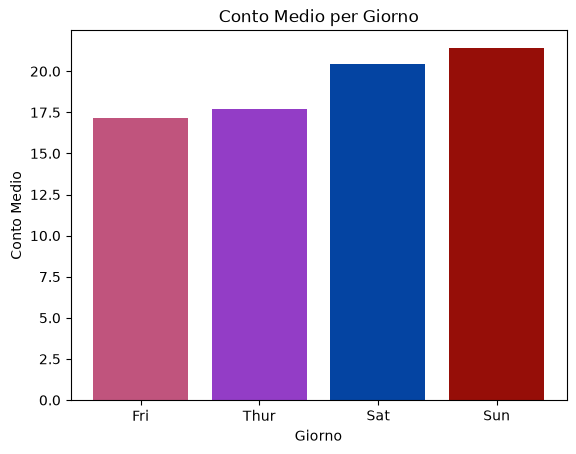

In [ ]:
# Grafico 

dati = df_clean.groupby('day')['total_bill'].mean()
dati = dati.sort_values()

cat = dati.index
val = dati.values
col = np.random.rand(len(cat), 3)

plt.bar(cat,val, color = col)
plt.title('Conto Medio per Giorno')
plt.xlabel('Giorno')
plt.ylabel('Conto Medio')
